# Práctica 4: Calidad y Minería de datos - Python
Mariana Urrego, Natalia Urrego, Sebastian Villa, Steve Ellis

## Punto 1 - CALIDAD DE DATOS



Genere el perfilado de datos en Python sobre los datos originales, adjunte el resultado en HTML.

Realice un diagnóstico de cada una de las dimensiones de la calidad de datos, teniendo en cuenta los resultados del perfilado. El diagnóstico debe estar en el notebook.

Implemente todos los pasos de limpieza y mejora de los datos en Python.


In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [ ]:
data = pd.read_csv("cybersecurity_intrusion_data.csv", keep_default_na=False)
data.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [ ]:
#Revisamos si tenemos ID repetidos
ids = data['session_id'].value_counts()
ids[ids > 1]

,count
session_id,


In [ ]:
data['unusual_time_access'] = data['unusual_time_access'].astype('category')
data['attack_detected'] = data['attack_detected'].astype('category')

#Corrección tipo de datos
for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = data[column].astype('category')

In [ ]:
data.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   session_id           9537 non-null   category
 1   network_packet_size  9537 non-null   int64   
 2   protocol_type        9537 non-null   category
 3   login_attempts       9537 non-null   int64   
 4   session_duration     9537 non-null   float64 
 5   encryption_used      9537 non-null   category
 6   ip_reputation_score  9537 non-null   float64 
 7   failed_logins        9537 non-null   int64   
 8   browser_type         9537 non-null   category
 9   unusual_time_access  9537 non-null   category
 10  attack_detected      9537 non-null   category
dtypes: category(6), float64(2), int64(3)
memory usage: 771.1 KB


# 2. Eliminar variables irrelevantes y redundantes
* Irrelevantes: cedulas, ids, nombres, telefonos, direcciones, códigos.
* Redundantes: validación por fórmula matemática que están repetidas

In [ ]:
# Variables irrelevantes para el proceso de minería
data = data.drop('session_id',axis=1) #Eliminamos el ID por ser irrelevante, axis=1 indica que es una columna
data.head()

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


3. Descripción estadística


In [ ]:
data.describe()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773
std,198.379364,1.963012,786.560144,0.177175,1.033988
min,64.000000,1.000000,0.500000,0.002497,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000


**Variables numéricas**

array([[<Axes: title={'center': 'network_packet_size'}>,
        <Axes: title={'center': 'login_attempts'}>],
       [<Axes: title={'center': 'session_duration'}>,
        <Axes: title={'center': 'ip_reputation_score'}>],
       [<Axes: title={'center': 'failed_logins'}>, <Axes: >]],
      dtype=object)

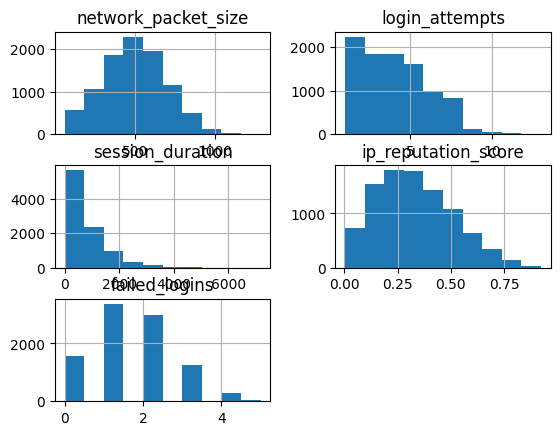

In [ ]:
data.hist()

<Axes: >

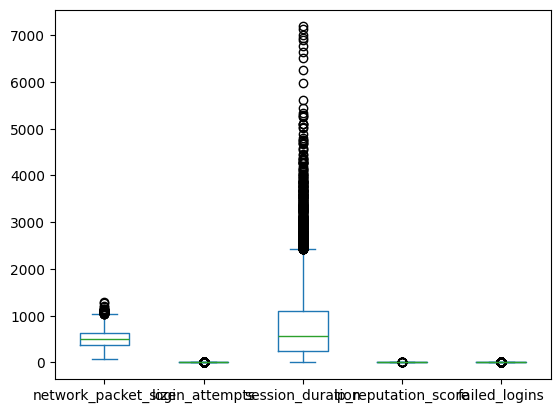

In [ ]:
data.plot.box()

Variables categóricas (value_counts())

<Axes: xlabel='protocol_type'>

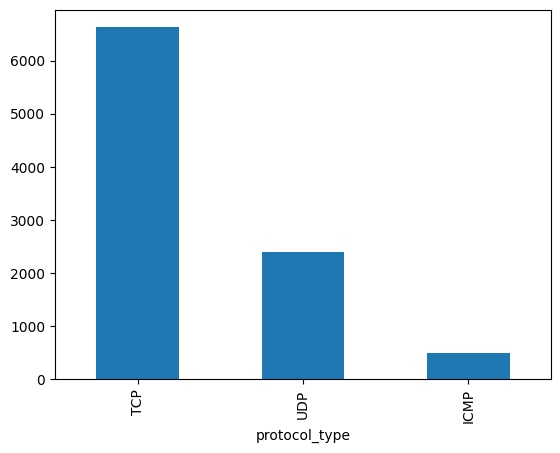

In [ ]:
#Conocemos las variables categóricas: bar, barh, pie
data['protocol_type'].value_counts().plot(kind='bar')

<Axes: ylabel='encryption_used'>

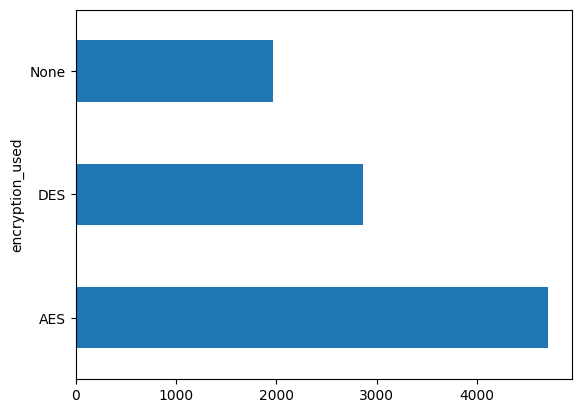

In [ ]:
 #Conocemos las variables categóricas: bar, barh, pie
data['encryption_used'].value_counts().plot(kind='barh')

Gráficas de las relaciones entre variables

<Axes: xlabel='browser_type', ylabel='session_duration'>

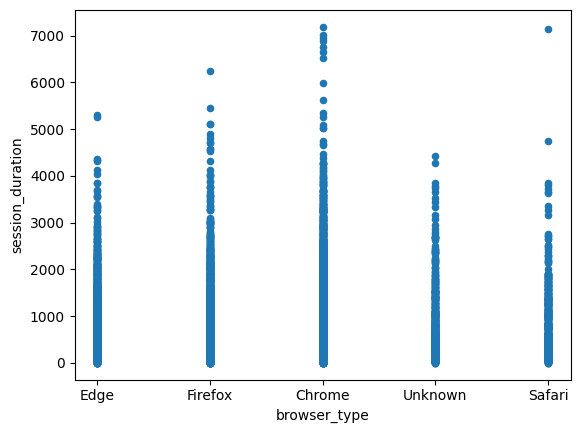

In [ ]:
#Conocemos las variables categóricas: bar, barh, pie

data.plot.scatter(x='browser_type',y='session_duration')

Perfilado de datos

In [ ]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True) # minimal=True
profile_data

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 71.14it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Dimensiones de la Calidad de Datos**

**Completitud:** ¿Está toda la información disponible? ¿Hay datos faltantes o ausentes?

**Exactitud:**¿La información es correcta y libre de error?

**Conformidad:** ¿Los valores de los datos están conformes con los formatos esperados? Ejemplo: Una fecha en formato AAAA/MM/DD cuando debería ser DD/MM/AAAA.

**Oportunidad:** ¿La información llega cuando se necesita?

**Duplicidad:** ¿Existen múltiples instancias, innecesarias de los mismos objetos de datos en el conjunto de datos?

**Integridad:** ¿Faltan datos relacionados importantes? ¿Es clara la conectividad y las relaciones con otros datos?

Diagnóstico de las dimensiones según el perfilado:

Completitud: Si, está todo disponible

Exactitud: La información es correcta

Conformidad: Si, todo en orden

Oportunidad: No aplica, no se puede verificar con los datos disponibles. En un entorno de producción real, esta dimensión sería crítica para sistemas de detección de intrusiones en tiempo real

Duplicidad: No hay problemas de duplicidad en el dataset.

Integridad: No se detectaron problemas de integridad. Las variables tienen relaciones lógicas claras dentro del contexto de ciberseguridad.

# 4. Limpieza de datos atípicos-errores
- Sólo se limpian errores

*No se eliminan, ya que los zeros en los registros indican ausencia de fallas al iniciar sesión, lo cual no es un mal registro. el ataque se llevó a cabo a el primer intento*

5. Limpieza de datos nulos: Imputación

Estrategia:

Eliminar registros con mas de 15% de nulos
Eliminar columnas con mas de 15%-20% de nulos
Imputar por media, moda, mediana, vecinos cercanos. No se puede imputar más allá del 15% de los datos.
Para casos especiales se crea modelo predictivo

6. Correlaciones para redundancias

In [ ]:
# Todas las variables deben ser numéricas para calcular las correlaciones
# Se crean dummies para las variables categóricas

data_num = pd.get_dummies(data, drop_first=True, dtype=int)
data_num.head()

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,protocol_type_TCP,protocol_type_UDP,encryption_used_DES,encryption_used_None,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown,unusual_time_access_1,attack_detected_1
0,599,4,492.983263,0.606818,1,1,0,1,0,1,0,0,0,0,1
1,472,3,1557.996461,0.301569,0,1,0,1,0,0,1,0,0,0,0
2,629,3,75.044262,0.739164,2,1,0,1,0,0,0,0,0,0,1
3,804,4,601.248835,0.123267,0,0,1,1,0,0,0,0,1,0,1
4,453,5,532.540888,0.054874,1,1,0,0,0,0,1,0,0,0,0


Correlaciones para redundacia= mayores |0.8|

In [ ]:
#Correlaciones
correlaciones=data_num.corr()
correlaciones

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,protocol_type_TCP,protocol_type_UDP,encryption_used_DES,encryption_used_None,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown,unusual_time_access_1,attack_detected_1
network_packet_size,1.000000,-0.001890,0.021650,0.002320,-0.011676,-0.017863,0.016565,0.009977,0.008647,-0.005308,0.017610,0.013130,0.002234,-0.001255,-0.006798
login_attempts,-0.001890,1.000000,0.006392,-0.002618,-0.013507,-0.023837,0.026665,0.002339,0.000254,0.000720,0.002735,-0.007188,-0.004092,0.007349,0.277320
session_duration,0.021650,0.006392,1.000000,-0.005077,0.019375,0.010986,-0.007982,-0.008657,0.008510,-0.012287,-0.001914,0.010599,0.003758,0.012930,0.041602
ip_reputation_score,0.002320,-0.002618,-0.005077,1.000000,0.015613,-0.022273,0.030000,-0.011392,0.006522,0.002337,0.001258,0.017507,-0.007540,-0.003146,0.211540
failed_logins,-0.011676,-0.013507,0.019375,0.015613,1.000000,0.010408,-0.009051,0.005216,-0.010514,0.002919,-0.002404,0.004561,-0.003144,0.006131,0.363726
protocol_type_TCP,-0.017863,-0.023837,0.010986,-0.022273,0.010408,1.000000,-0.875916,0.002032,0.013224,0.013681,0.005526,0.009470,-0.021070,-0.005240,0.000643
protocol_type_UDP,0.016565,0.026665,-0.007982,0.030000,-0.009051,-0.875916,1.000000,0.000640,-0.018491,-0.008427,0.000340,-0.006985,0.023087,0.004219,0.007903
encryption_used_DES,0.009977,0.002339,-0.008657,-0.011392,0.005216,0.002032,0.000640,1.000000,-0.333925,0.004245,0.010223,-0.008014,-0.015164,-0.001656,0.008306
encryption_used_None,0.008647,0.000254,0.008510,0.006522,-0.010514,0.013224,-0.018491,-0.333925,1.000000,-0.012082,0.010459,0.003563,0.001759,-0.004201,0.016161
browser_type_Edge,-0.005308,0.000720,-0.012287,0.002337,0.002919,0.013681,-0.008427,0.004245,-0.012082,1.000000,-0.215908,-0.098770,-0.100581,0.005479,-0.008057


<Axes: >

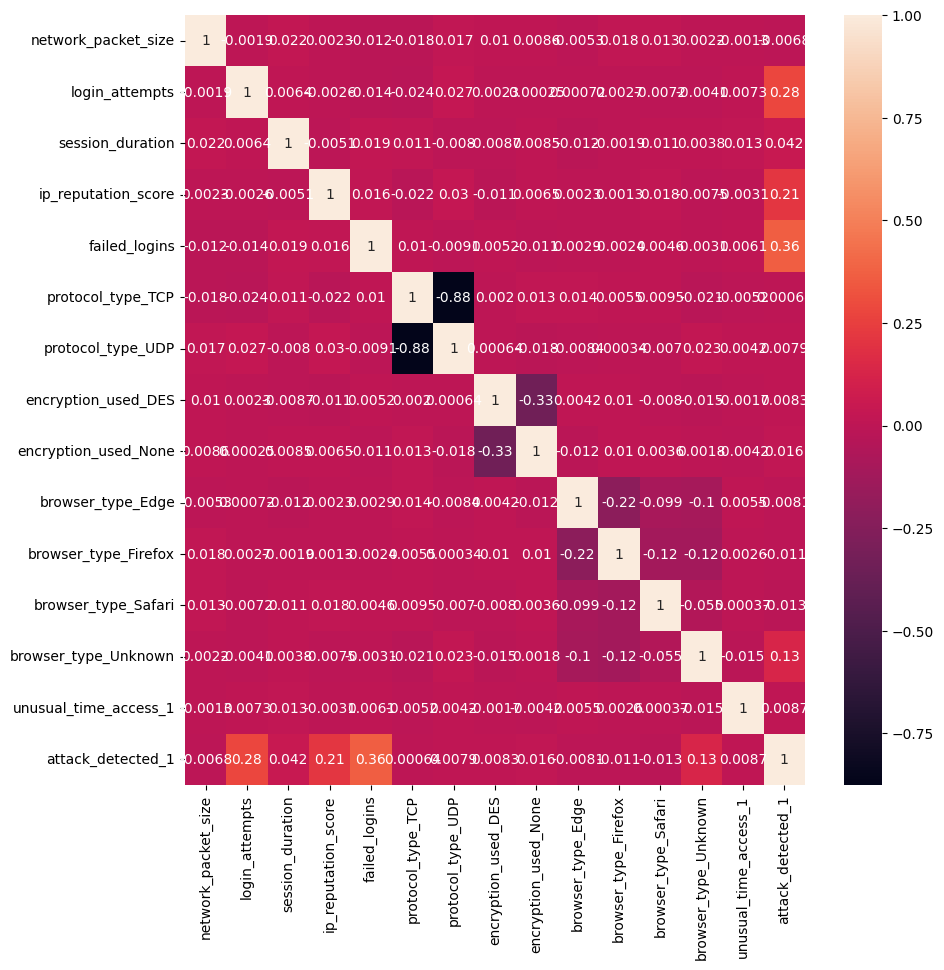

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(data_num.corr(),annot=True)

In [ ]:
#Correlaciones con la variable de objetivo
cor_variable_obj=correlaciones.loc['attack_detected_1']
cor_variable_obj

,attack_detected_1
network_packet_size,-0.006798
login_attempts,0.277320
session_duration,0.041602
ip_reputation_score,0.211540
failed_logins,0.363726
protocol_type_TCP,0.000643
protocol_type_UDP,0.007903
encryption_used_DES,0.008306
encryption_used_None,0.016161
browser_type_Edge,-0.008057


Las correlaciones de casi la mayoria de las variables es demasiado baja, pero no se eliminan ya que se quedaria sin variables, se eliminan solamente las que tienen un valor mas mas bajo de correlación.

In [ ]:
#Detección de irrelevantes = se buscan correlaciones con la variable objetivo muy bajas (0.0-0.05 ) ->ultima fila
columns_to_drop = ['protocol_type', 'network_packet_size', 'unusual_time_access']
data = data.drop(columns=columns_to_drop)
display(data.head())

,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,attack_detected
0,4,492.983263,DES,0.606818,1,Edge,1
1,3,1557.996461,DES,0.301569,0,Firefox,0
2,3,75.044262,DES,0.739164,2,Chrome,1
3,4,601.248835,DES,0.123267,0,Unknown,1
4,5,532.540888,AES,0.054874,1,Firefox,0


# 8. Guardar los datos preparados

In [ ]:
data.to_excel('./datos_limpios.xlsx')

FIN